# **Tommato leave disease classifiction using CNN **

In [1]:
# kaggle commands to lead the datasets
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [2]:
# loading kaustubhb999/tomatoleaf data
!kaggle datasets download -d kaustubhb999/tomatoleaf

Dataset URL: https://www.kaggle.com/datasets/kaustubhb999/tomatoleaf
License(s): CC0-1.0
tomatoleaf.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
# getting the root path
import os
root_dir = os.path.abspath('/content/tomato')
root_dir

'/content/tomato'

In [4]:
# getting how many folders we have and how many iamges we have
folders = os.listdir(root_dir + '/tomato')
print(folders)

['train', 'val', 'cnn_train.py']


In [5]:
# so root dir is /tomato/tomato
root_dir = '/content/tomato/tomato'

In [6]:
print(len(os.listdir(root_dir+'/train')))
os.listdir(root_dir+'/train') #<--- categories of disease

10


['Tomato___Septoria_leaf_spot',
 'Tomato___Target_Spot',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___healthy',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Spider_mites Two-spotted_spider_mite']

In [7]:
categoires = os.listdir(root_dir+'/train')

for cat ,img in enumerate(categoires):
  print(categoires[cat],'   :   ',len(os.listdir(root_dir+'/train/'+img)))

Tomato___Septoria_leaf_spot    :    1000
Tomato___Target_Spot    :    1000
Tomato___Bacterial_spot    :    1000
Tomato___Early_blight    :    1000
Tomato___Late_blight    :    1000
Tomato___Leaf_Mold    :    1000
Tomato___healthy    :    1000
Tomato___Tomato_mosaic_virus    :    1000
Tomato___Tomato_Yellow_Leaf_Curl_Virus    :    1000
Tomato___Spider_mites Two-spotted_spider_mite    :    1000


In [8]:
# for test
test_categories = os.listdir(root_dir+'/val')

for cat, img in enumerate(test_categories):
  print(test_categories[cat],'   :   ',len(os.listdir(root_dir+'/val/'+img)))

Tomato___Septoria_leaf_spot    :    100
Tomato___Target_Spot    :    100
Tomato___Bacterial_spot    :    100
Tomato___Early_blight    :    100
Tomato___Late_blight    :    100
Tomato___Leaf_Mold    :    100
Tomato___healthy    :    100
Tomato___Tomato_mosaic_virus    :    100
Tomato___Tomato_Yellow_Leaf_Curl_Virus    :    100
Tomato___Spider_mites Two-spotted_spider_mite    :    100


In [9]:
# seeing the image of each categories
import matplotlib.pyplot as plt


for category_name in categoires:
  plt.figure(figsize=(5,3))
  category_path = os.path.join(root_dir, 'train', category_name)
  images_in_category = os.listdir(category_path)

  for j in range(min(2, len(images_in_category))):
    plt.subplot(1, 2, j + 1) # Subplot index is 1-based
    img_path = os.path.join(category_path, images_in_category[j])
    plt.imshow(plt.imread(img_path))
    plt.title(f"{category_name.replace('___', ' ')} - Sample {j+1}") # Nicer title format
    plt.axis('off') # Hide axes for cleaner display
  plt.tight_layout()
  plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [10]:
# preparing the iamges in test and train for the model building
import cv2

test_data = []
validation_data = []
test_label = []
val_label = []

for category_name in test_categories:
  category_path = os.listdir(root_dir + '/train/' + category_name)
  for img in category_path:
    img_path = os.path.join(root_dir, 'train', category_name, img)
    img = plt.imread(img_path)
    img = cv2.resize(img, (224, 224))
    test_label.append(category_name.split('___')[-1])
    test_data.append(img)

In [11]:
test_categories

['Tomato___Septoria_leaf_spot',
 'Tomato___Target_Spot',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___healthy',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Spider_mites Two-spotted_spider_mite']

In [12]:
len(test_label) , len(test_data)

(10000, 10000)

array([[[ 99,  86, 106],
        [ 97,  84, 104],
        [103,  90, 110],
        ...,
        [ 99,  85, 100],
        [ 98,  84,  99],
        [ 91,  77,  91]],

       [[109,  96, 116],
        [105,  92, 112],
        [107,  94, 114],
        ...,
        [ 98,  84,  99],
        [ 97,  83,  98],
        [ 93,  79,  94]],

       [[106,  93, 113],
        [105,  92, 112],
        [107,  94, 114],
        ...,
        [ 98,  84,  98],
        [ 97,  83,  98],
        [ 94,  80,  95]],

       ...,

       [[143, 134, 155],
        [144, 135, 156],
        [147, 138, 159],
        ...,
        [156, 143, 161],
        [156, 143, 161],
        [158, 145, 163]],

       [[145, 136, 157],
        [145, 137, 158],
        [147, 138, 159],
        ...,
        [155, 142, 160],
        [156, 143, 161],
        [162, 149, 167]],

       [[150, 141, 162],
        [148, 139, 160],
        [147, 138, 159],
        ...,
        [160, 147, 165],
        [158, 145, 163],
        [165, 152, 170]]], dtype=uint8)
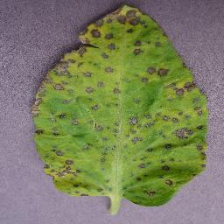

In [13]:
test_data[0]

In [14]:
# same with validation
for category_name in test_categories:
  category_path = os.listdir(root_dir + '/val/' + category_name)
  for img in category_path:
    img_path = os.path.join(root_dir, 'val', category_name ,img)
    img = plt.imread(img_path)
    img = cv2.resize(img, (224, 224))
    val_label.append(category_name.split('___')[-1])
    validation_data.append(img)

In [15]:
len(val_label) , len(validation_data)

(1000, 1000)

In [17]:
# processing the images in train data
import numpy as np
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
train_label = encoder.fit_transform(test_label)
train_label = np.array(train_label)

# with validation
val_label = encoder.fit_transform(val_label)
val_label = np.array(val_label)

# which label reprsent which disease
for i in encoder.classes_:
   print(i ,':',categoires[i])

0 : Tomato___Septoria_leaf_spot
1 : Tomato___Target_Spot
2 : Tomato___Bacterial_spot
3 : Tomato___Early_blight
4 : Tomato___Late_blight
5 : Tomato___Leaf_Mold
6 : Tomato___healthy
7 : Tomato___Tomato_mosaic_virus
8 : Tomato___Tomato_Yellow_Leaf_Curl_Virus
9 : Tomato___Spider_mites Two-spotted_spider_mite


In [18]:
# first converting test and validation to an array
test_data = np.array(test_data)
validation_data = np.array(validation_data)

In [19]:
test_data.shape , validation_data.shape

((10000, 224, 224, 3), (1000, 224, 224, 3))

In [88]:
import tensorflow as tf
from tensorflow.keras import layers, models


model = models.Sequential([

    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    # First Convolutional block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Convolutional block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten and Dense layers
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_14 (Rescaling)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_44 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,250 (42.61 MB)

 Trainable params: 11,170,250 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# shuffling all the images and lables so that model will train fro better generalisation
from sklearn.utils import shuffle
test_data, train_label = shuffle(test_data, train_label, random_state=42)
validation_data, val_label = shuffle(validation_data, val_label, random_state=42)

In [77]:
train_label[:20]

array([8, 7, 2, 3, 6, 5, 5, 5, 5, 3, 1, 3, 7, 5, 2, 2, 8, 8, 0, 2])

In [90]:
history = model.fit(
    test_data, train_label,
    epochs=15,
    validation_data=(validation_data, val_label)
)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 66ms/step - accuracy: 0.5027 - loss: 1.4360 - val_accuracy: 0.7530 - val_loss: 0.7405
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.7269 - loss: 0.7998 - val_accuracy: 0.7860 - val_loss: 0.6003
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.7816 - loss: 0.6229 - val_accuracy: 0.8450 - val_loss: 0.4533
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.8211 - loss: 0.5189 - val_accuracy: 0.8160 - val_loss: 0.5407
Epoch 5/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.8541 - loss: 0.4210 - val_accuracy: 0.8570 - val_loss: 0.4362
Epoch 6/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.8680 - loss: 0.3857 - val_accuracy: 0.8400 - val_loss: 0.4986
Epoch 7/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.8817 - loss: 0.3408 - val_accuracy: 0.8090 - val_loss: 0.6669
Epoch 8/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.8892 - loss: 0.3277 - 

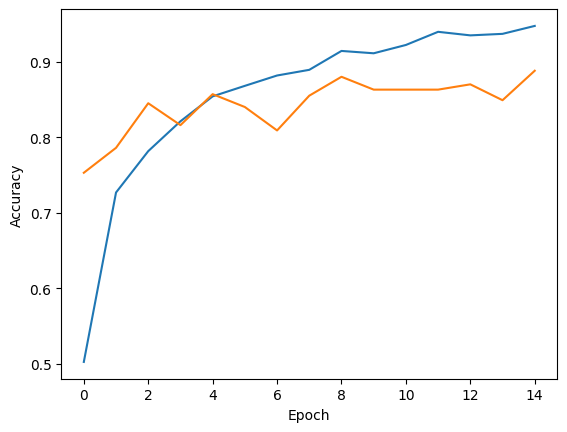

In [91]:
# interpreting the results
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

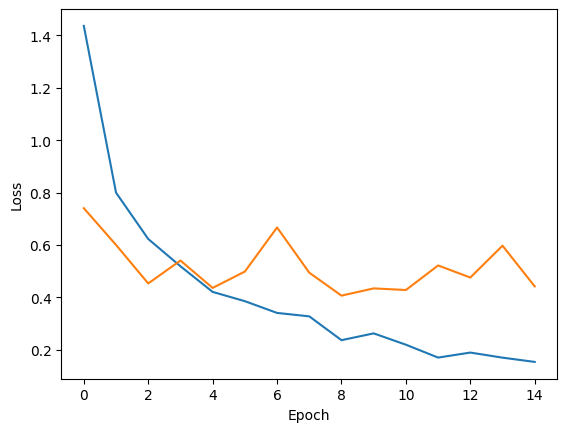

In [92]:
# loss
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


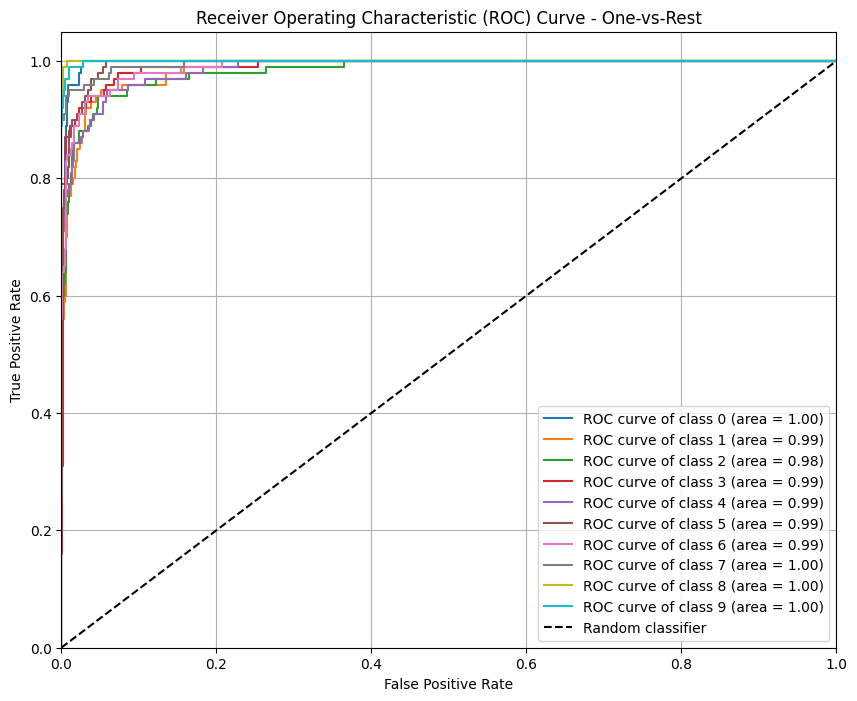

In [93]:
# roc auc graph
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

# Get predicted probabilities for the validation data
y_pred_proba = model.predict(validation_data)

# Binarize the true labels for multi-class ROC
label_binarizer = LabelBinarizer()
y_true_binarized = label_binarizer.fit_transform(val_label)

# Plot ROC curve for each class
plt.figure(figsize=(10, 8))
for i in range(len(encoder.classes_)):
    fpr, tpr, thresholds = roc_curve(y_true_binarized[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve of class {encoder.classes_[i]} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - One-vs-Rest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()